# Анализ рынка заведений общественного питания Москвы



### Цели и задачи проекта

Цель проекта — проанализировать рынок заведений общественного питания Москвы и выявить особенности размещения, формата и характеристик заведений с высоким рейтингом, чтобы помочь заказчику выбрать оптимальный формат и параметры для открытия нового заведения. 

Задачи проекта

1. Изучить структуру и качество исходных данных о заведениях общественного питания Москвы, выполнить предобработку и объединение доступных датасетов.

2. Проанализировать распределение заведений по типам (кафе, ресторан, кофейня, пиццерия и др.), районам города и принадлежности к сетям.

3. Исследовать зависимости рейтинга от ключевых характеристик: типа заведения, административного округа, ценовой категории, количества посадочных мест, режима работы и сетевого формата.

4. Выделить наиболее распространённые и успешные сети (по числу точек и среднему рейтингу), определить, какие форматы показывают стабильные высокие оценки гостей.

5. Сформулировать выводы и практические рекомендации по выбору формата, ценового сегмента и локации для нового заведения заказчика на основе результатов анализа.

### Описание данных

В проекте используются два набора данных о заведениях общественного питания Москвы.

Первый датасет rest_info.csv содержит основную информацию о заведениях:
id — уникальный идентификатор заведения;

name — название заведения;

category — тип заведения (кафе, ресторан, кофейня, пиццерия, быстрое питание, столовая и др.);

address — адрес заведения;

district — административный округ Москвы;

hours — режим работы (часы и дни недели);

rating — пользовательский рейтинг заведения;

chain — признак принадлежности к сети (0 — несетевое заведение, 1 — сетевое);

seats — количество посадочных мест.

Второй датасет rest_price.csv дополняет данные информацией о ценовом уровне:

id — идентификатор заведения, используется для объединения таблиц;

price — категория ценового сегмента (например, «средние», «выше среднего»);

avg_bill — текстовое описание среднего счёта;

middle_avg_bill — числовая оценка среднего счёта;

middle_coffee_cup — средняя стоимость чашки кофе, если указана.

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними



In [1]:
# Загружаем библиотеки
import pandas as pd

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

#Для расчета коэффициента корреляции
!pip install phik
from phik import phik_matrix

In [2]:
#Выгружаем датасеты
df_info=pd.read_csv('/datasets/rest_info.csv')
df_price=pd.read_csv('/datasets/rest_price.csv')

In [3]:
# Выводим первые строки датафрейма df_info
df_info.head()


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# выводим информацию о датафрейме df_info
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# смотрим отдельно количество пустых значений df_info
df_info.isna().sum()

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [6]:
# Выводим первые строки датафрейма df_price
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# выводим информацию о датафрейме df_price
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# смотрим отдельно количество пустых значений df_price
df_price.isna().sum()

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

---

### Промежуточный вывод



Информация содержится в двух датасетах. Первый df_info содержит 8406 строк с информацией о названии, адресе, категории, административном округе, рейтинге, сетевом статусе и количестве посадочных мест. Для стобцов hours и seats наблюдается заметное количество пропусков, 536 и 3611 соответственно, что важно учитывать при дальнейшем анализе. Структура и состав столбцов соответствуют описанию данных: идентификатор и текстовые поля хранятся в строковом формате, рейтинг представлен в виде числа с плавающей точкой, сетевой статус — в виде целочисленного признака 0/1, количество посадочных мест - в виде числа с плавающей точкой из-за наличия пропусков NaN.

Второй датасет включает 4058 записей по ценовым категориям и среднему чеку. Во всех столбцах, кроме идентификатора id, присутствуют пропуски, при этом признак middle_coffee_cup заполнен лишь для небольшой части заведений. Формат столбцов соответствует описанию данных: ценовые категории и текстовое описание счёта представлены строками, а оценка среднего чека и стоимости чашки кофе — числовыми признаками.

Оба датасета связаны по идентификатору id, что позволяет объединить их в единый датафрейм для дальнейшего исследования.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [9]:
# объединяем датафреймы
df = df_info.merge(df_price, on='id', how='left')

In [10]:
# выводим информацию о датафрейме df
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [11]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
tmp = df.copy()
len(tmp)

8406

## 2. Предобработка данных


In [12]:
# Переводим столбец price в категориальный
df['price'] = df['price'].astype('category')

In [13]:
# Проверяем
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   object  
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int64   
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(1), float64(4), int64(1), object(7)
memory usage: 862.1+ KB


Чтобы необходимые числовые столбцы перевести в подходящий тип, сначала нужно решить, что делать с пропусками.

In [14]:
# Считаем пропуски
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

<div class="alert alert-info">
<b> Добавляю проверку долей пропусков</b> 
</div>

In [15]:
# Считаем долю пропусков по столбцам
missing_percent = df.isna().sum() / df.shape[0] * 100

missing_percent.sort_values(ascending=False)


middle_coffee_cup    93.635498
middle_avg_bill      62.538663
price                60.563883
avg_bill             54.603854
seats                42.957411
hours                 6.376398
id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
rating                0.000000
chain                 0.000000
dtype: float64

Больше всего пропусков в столбце middle_coffee_cup (93.6%), а также в middle_avg_bill (62.5%), price (60.5%) и avg_bill (54.6%). Пропуски в seats составляют около 43%. В остальных столбцах пропусков нет.

In [16]:
# Проверка дубликатов в id
df['id'].duplicated().sum()

0

In [17]:
# Проверка дубликатов в name
df['name'].duplicated().sum()

2792

In [18]:
# Проверка дубликатов в address 
df['address'].duplicated().sum()

2653

In [19]:
# Нормальзация строк в name
df['name_clear'] = df['name'].str.lower().str.strip()

In [20]:
# Нормализация строк в address
df['address_clear'] = df['address'].str.lower().str.strip()

In [21]:
# Смотрим пару дубликатов название + адрес
df.duplicated(subset=['name_clear', 'address_clear']).sum()

4

In [22]:
# удаляем дубликаты по нормализованным названию и адресу
df = df.drop_duplicates(subset=['name_clear', 'address_clear'])

In [23]:
# Количество строк после удаления
len(df)

8402

In [24]:
# функция для признака круглосуточной работы
def is_24_7(hours):
    # если значение пропущено    
    if pd.isna(hours):
        return False
    
    # приводим к нижнему регистру
    hours_lower = hours.lower()
    
    # проверяем наличие слова "круглосуточно"
    if 'круглосуточно' in hours_lower:
        return True
    else:
        return False

In [25]:
# применяем функцию создаём новый столбец
df['is_24_7'] = df['hours'].apply(is_24_7)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8402 non-null   object  
 1   name               8402 non-null   object  
 2   category           8402 non-null   object  
 3   address            8402 non-null   object  
 4   district           8402 non-null   object  
 5   hours              7867 non-null   object  
 6   rating             8402 non-null   float64 
 7   chain              8402 non-null   int64   
 8   seats              4792 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  name_clear         8402 non-null   object  
 14  address_clear      8402 non-null   object  
 15  is_24_7            8402 non-null   bool    
dtypes: boo

In [27]:
#Уникальные значения в столбце is_24_7
df['is_24_7'].value_counts()

False    7630
True      772
Name: is_24_7, dtype: int64

In [28]:
# Проверим сколько удалено строк датасета
a = len(tmp)
b = len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод



В объединённом датафрейме присутствуют пропуски в нескольких столбцах. В стобце hours отсутствует 536 значений: для этих заведений в источнике не указана информация о режиме работы. В столбце seats зафиксировано 3611 пропусков, что говорит о том, что для значительной доли объектов неизвестно количество посадочных мест.
В ценовом блоке данные представлены неполно: признаки price и avg_bill содержат пропуски более чем у половины заведений, а числовой показатель middle_avg_bill рассчитан лишь для части строк, где в текстовом описании явно указан «Средний счёт». Признак middle_coffee_cup заполнен для очень небольшого числа записей и носит вспомогательный характер.
На этапе предобработки пропуски в этих столбцах не заполнялись и строки не удалялись, чтобы не сокращать выборку и не искажать распределения. В дальнейшем анализе показатели, связанные с количеством посадочных мест и ценами, будут рассчитываться только для тех заведений, где соответствующие значения присутствуют, а наличие пропусков будет учитываться при интерпретации результатов.

Для поиска неявных дубликатов были нормализованы строки: названия и адреса заведений приведены к нижнему регистру и очищены от лишних пробелов. После этого выполнена проверка дубликатов по сочетанию названия и адреса. В данных обнаружено 4 дубликата, соответствующие повторяющимся записям одних и тех же заведений. Они были удалены с помощью метода drop_duplicates, в результате чего объём датафрейма сократился с 8406 до 8402 строк (0,05%).

На основе столбца hours был сформирован новый булевый стобец is_24_7, отражающий факт круглосуточной работы заведения. Значение True присвоилось объектам, в расписании которых присутствует указание «круглосуточно», во всех остальных случаях (включая пропуски в hours) признак принимает значение False. 

## 3. Исследовательский анализ данных


---

### Задача 1



In [29]:
# Проверяем распределение данных по значениям столбца category 
print('Распределение данных по значениям столбца category:')
df['category'].value_counts()

Распределение данных по значениям столбца category:


кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

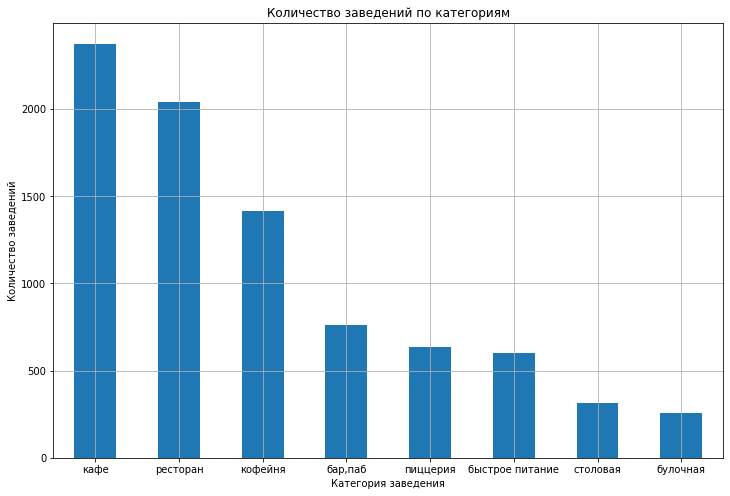

In [30]:
# Построим столбчатую диаграмму

df['category'].value_counts().plot(
              figsize=(12, 8),
              kind='bar',
              rot=0,
              legend=False,
              title='Количество заведений по категориям',
              xlabel='Категория заведения',
              ylabel='Количество заведений')
plt.grid()

plt.show()

На графике видно, что в Москве преобладают заведения формата кафе и ресторанов. Следующую по численности группу составляют кофейни. Менее всего представлены столовые и булочные, а пиццерии и заведения быстрого питания занимают промежуточное положение. 

In [31]:
# Посмотрим на доли
cat_share = df['category'].value_counts() / df['category'].value_counts().sum() * 100
cat_share

кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64

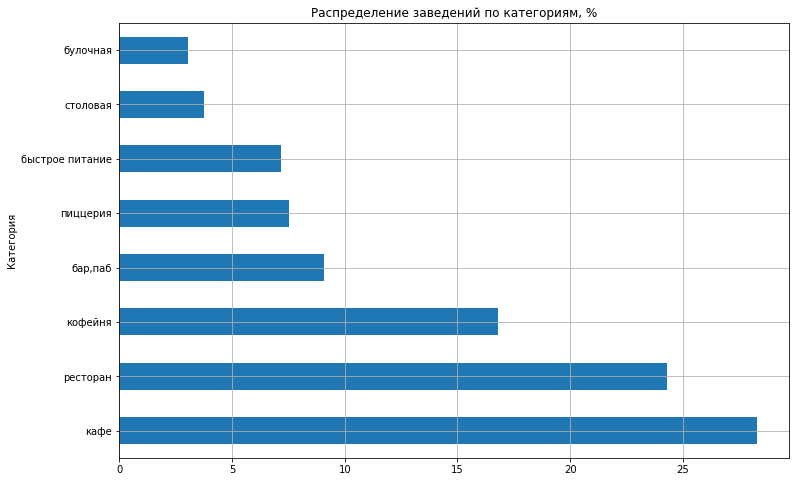

In [32]:
# Визуализируем
cat_share.plot(kind='barh',
               figsize=(12, 8),
               ylabel='Доля, %',
               xlabel='Категория',
               title='Распределение заведений по категориям, %')
plt.grid()
plt.show()

Больше всего заведений относится к категориям «кафе» (28%) и «ресторан» (24%). Далее идут «кофейни» (17%), «бар,паб» (9%), «пиццерии» (7.5%) и «быстрое питание» (7%). «Столовые» и «булочные» встречаются реже — около 3–4% от всех заведений.

---

### Задача 2



In [33]:
# Распределение заведений по административным районам
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

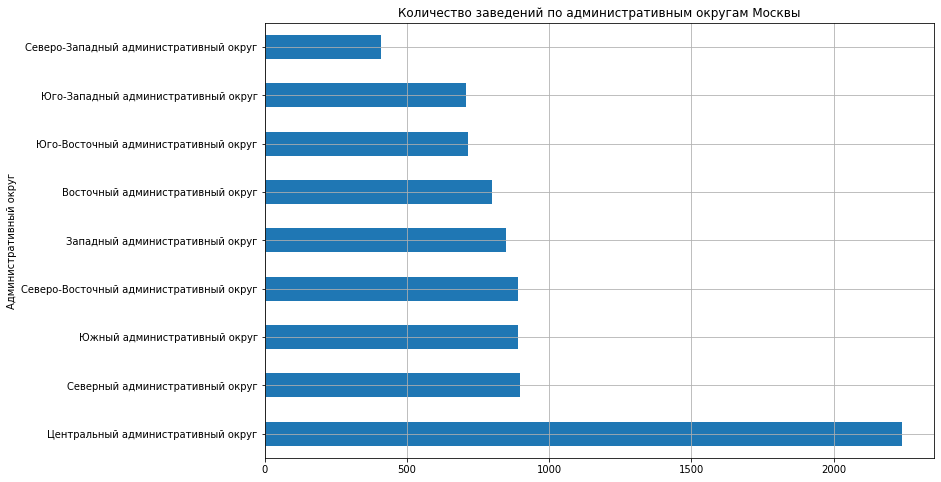

In [34]:
# Построим линейчатую диаграмму

df['district'].value_counts().plot(
              figsize=(12, 8),
              kind='barh',
              rot=0,
              legend=False,
              title='Количество заведений по административным округам Москвы',
              xlabel='Административный округ',
              ylabel='Количество заведений')

plt.grid()
plt.show()

In [35]:
# Посмотрим на доли
df_dis = df['district'].value_counts()
dis_share = df_dis / df_dis.sum() * 100
dis_share

Центральный административный округ         26.684123
Северный административный округ            10.687931
Южный административный округ               10.616520
Северо-Восточный административный округ    10.592716
Западный административный округ            10.116639
Восточный административный округ            9.497739
Юго-Восточный административный округ        8.497977
Юго-Западный административный округ         8.438467
Северо-Западный административный округ      4.867889
Name: district, dtype: float64

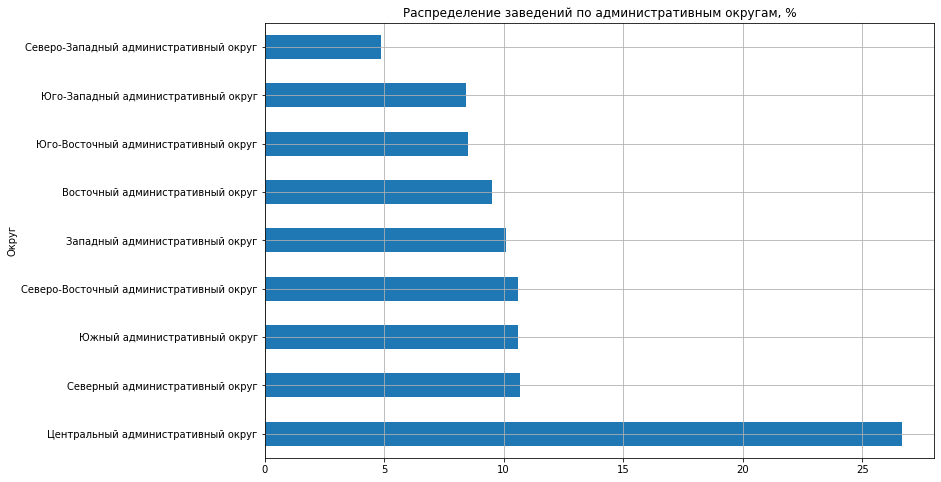

In [36]:
# Визуализируем
dis_share.plot(kind='barh',
               figsize=(12, 8),
               ylabel='Доля заведений, %', 
               xlabel='Округ',
               title='Распределение заведений по административным округам, %')
plt.grid()
plt.show()


Больше всего заведений расположено в Центральном административном округе — около 27% всех объектов. На втором–пятом местах идут Северный, Южный, Северо‑Восточный и Западный округа (примерно по 10–11% каждый). Восточный, Юго‑Восточный и Юго‑Западный округа имеют доли порядка 8–10%. Меньше всего заведений в Северо‑Западном административном округе (около 4.9%).

In [37]:
# Распределение заведений в центральном административном округе
df_cao = df[df['district']=='Центральный административный округ']


df_cao['category'].value_counts()

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

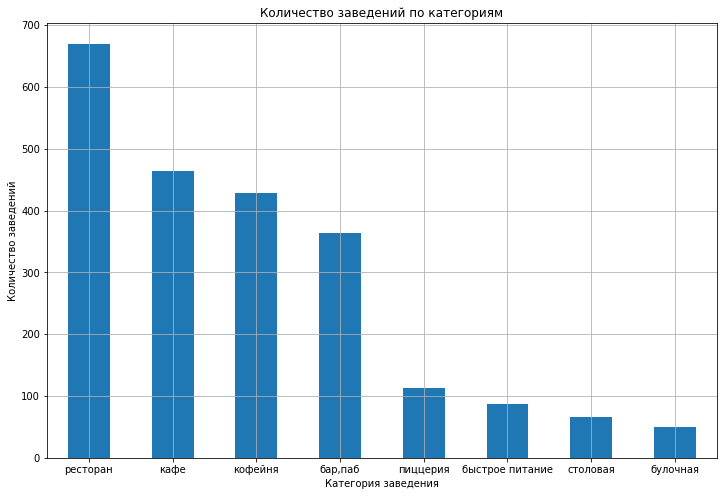

In [38]:
# Построим столбчатую диаграмму

df_cao['category'].value_counts().plot(
              figsize=(12, 8),
              kind='bar',
              rot=0,
              legend=False,
              title='Количество заведений по категориям',
              xlabel='Категория заведения',
              ylabel='Количество заведений')
plt.grid()

plt.show()

<div class="alert alert-info">
<b> Добавляю доли каждой категории по ЦАО</b> 
</div>

In [39]:
# Посмотрим на доли
cao_counts = df_cao['category'].value_counts()
cao_share = cao_counts / cao_counts.sum() * 100
cao_share

ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: category, dtype: float64

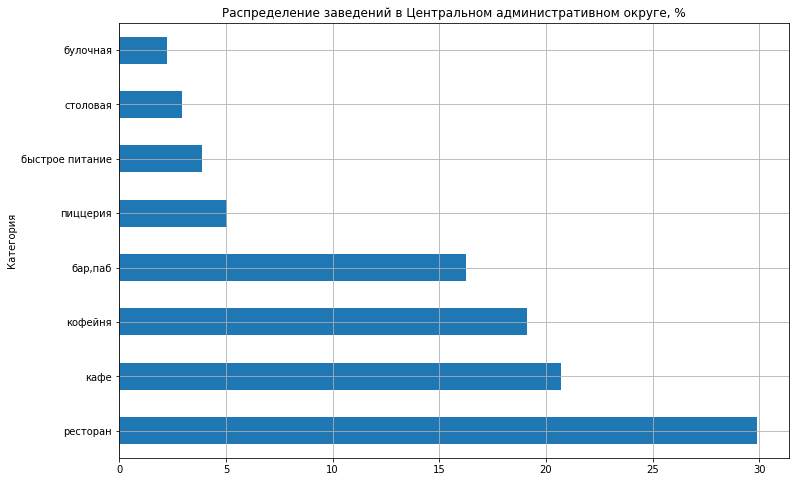

In [40]:
# Визуализируем
cao_share.plot(kind='barh',
               figsize=(12, 8),
               ylabel='Доля, %',
               xlabel='Категория',
               title='Распределение заведений в Центральном административном округе, %')
plt.grid()
plt.show()

В Центральном административном округе наибольшую долю занимают рестораны (около 30%) и кафе (21%), затем идут кофейни (19%) и бары/пабы (16%). Более редкие форматы — пиццерии, заведения быстрого питания, столовые и булочные, на них приходится существенно меньшая часть заведений. Это говорит о том, что округ ориентирован прежде всего на форматы «ресторан» и «кафе».

---

### Задача 3



In [41]:
# Смотрим количество заведений каждого типа
df['chain'].value_counts()

0    5199
1    3203
Name: chain, dtype: int64

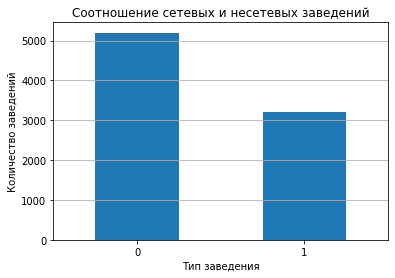

In [42]:
# Построим столбчатую диаграмму

df['chain'].value_counts().plot(
                           kind='bar',
                           figsize=(6, 4),
                           title='Соотношение сетевых и несетевых заведений',
                           xlabel='Тип заведения',
                           ylabel='Количество заведений',
                           rot=0)
plt.grid(axis='y')

На графике видно, что несетевых заведений (тип 0) больше, чем сетевых (тип 1): примерно 5200 против 3200. Одиночные заведения заметно преобладают над сетями в выборке.

In [43]:
# Посмотрим в долях
chain_counts = df['chain'].value_counts()
chain_share = chain_counts / chain_counts.sum() * 100
chain_share

0    61.878124
1    38.121876
Name: chain, dtype: float64

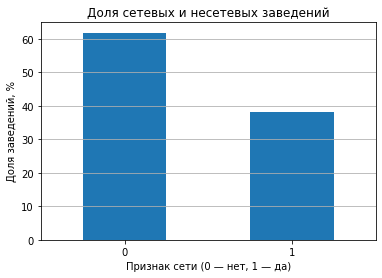

In [44]:
chain_share.plot(kind='bar',
               figsize=(6, 4),
               xlabel='Признак сети (0 — нет, 1 — да)',
               ylabel='Доля заведений, %',
               title='Доля сетевых и несетевых заведений',
                rot=0)
plt.grid(axis='y')
plt.show()

Сетевых заведений в выборке меньше, чем несетевых: доля несетевых объектов составляет примерно 62%, тогда как сетевые занимают около 38%. Это говорит о том, что рынок преимущественно представлен одиночными заведениями.

In [45]:
# Группируем данные по катерогиям и сетевому признаку 
cat_chain = df.groupby(['category', 'chain']).size().unstack(fill_value=0)
cat_chain

chain,0,1
category,,
"бар,паб",596,168
булочная,99,157
быстрое питание,371,232
кафе,1597,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,729
столовая,227,88


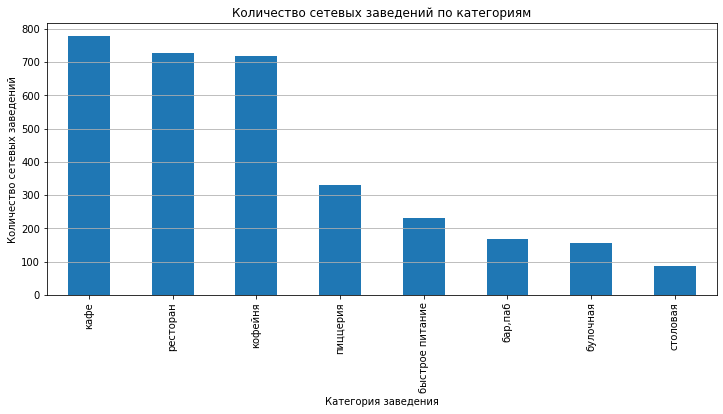

In [46]:
# Фильтруем только сетевые
df_chain = df[df['chain'] == 1]

# Строим диаграмму
df_chain['category'].value_counts().plot(
                                    kind='bar',
                                    figsize=(12,5),
                                    xlabel='Категория заведения',
                                    ylabel='Количество сетевых заведений',
                                    title='Количество сетевых заведений по категориям')

plt.grid(axis='y')

<div class="alert alert-info">
<b> Добавляю сетевые заведения в долях</b> 
</div>

In [47]:
# Сетевые заведения в долях
df_chain_share = df_chain['category'].value_counts()/ df_chain['category'].value_counts().sum() * 100
df_chain_share

кафе               24.320949
ресторан           22.759913
кофейня            22.478926
пиццерия           10.302841
быстрое питание     7.243209
бар,паб             5.245083
булочная            4.901655
столовая            2.747424
Name: category, dtype: float64

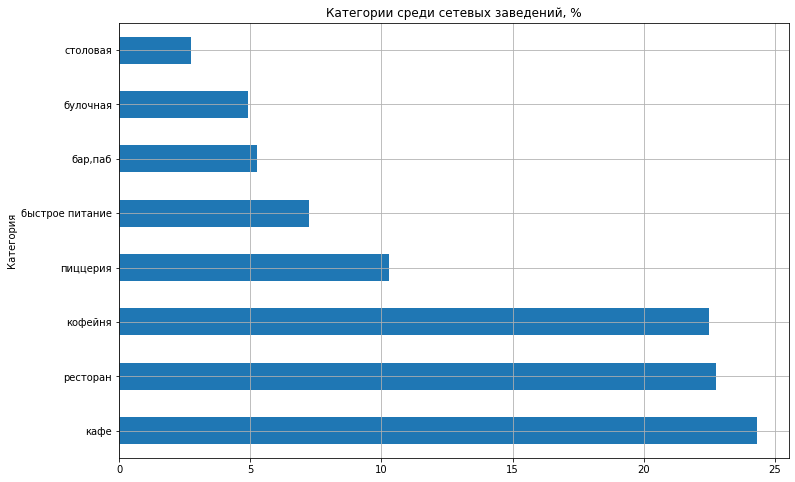

In [48]:
# Визуализируем
df_chain_share.plot(kind='barh',
               figsize=(12, 8),
               ylabel='Доля среди сетевых, %',
               xlabel='Категория',
               title='Категории среди сетевых заведений, %')
plt.grid()
plt.show()

Среди сетевых заведений лидируют «кафе», «ресторан» и «кофейня» — на каждую из этих категорий приходится около 22–24% всех сетевых объектов. Пиццерии (10%) и заведения быстрого питания (7%) занимают меньшую, но заметную долю, тогда как булочные (5%), бары/пабы (5%) и столовые (3%) представлены среди сетевых форматов существенно реже.

<div class="alert alert-info">
<b> Добавляю долю сетевых внутри каждой категории</b> 
</div>

In [49]:
# Доля сетевых внутри каждой category
cat_chain_share = df.groupby('category')['chain'].mean() * 100 
cat_chain_share

category
бар,паб            21.989529
булочная           61.328125
быстрое питание    38.474295
кафе               32.786195
кофейня            50.955414
пиццерия           52.132701
ресторан           35.700294
столовая           27.936508
Name: chain, dtype: float64

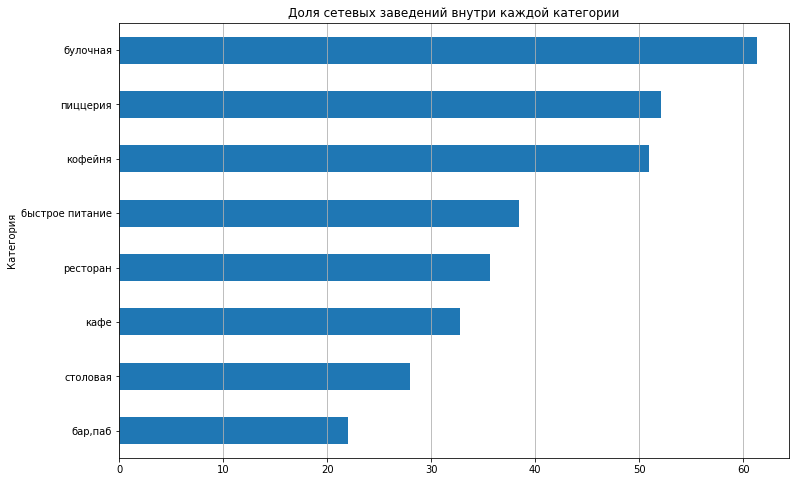

In [50]:
# Визуализируем
cat_chain_share.sort_values().plot(kind='barh',
               figsize=(12, 8),
               ylabel='Доля сетевых заведений, %',
               xlabel='Категория',
               title='Доля сетевых заведений внутри каждой категории')
plt.grid(axis='x')
plt.show()

Доля сетевых заведений заметно отличается между категориями. Наибольшая доля сетевых у булочных (около 61%), пиццерий (52%) и кофеен (51%), то есть эти форматы чаще развиваются в сетевом формате. В ресторанах и кафе доля сетевых ниже (примерно 36% и 33% соответственно), а наименьшие доли сетевых у баров/пабов (22%) и столовых (28%), что указывает на преобладание одиночных заведений в этих категориях.

---

### Задача 4




Text(0, 0.5, 'Количество посадочных мест')

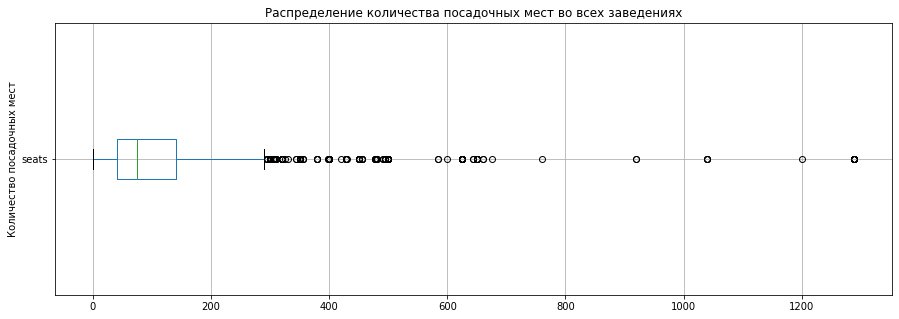

In [51]:
# Строим диаграмму размаха значений в столбце seats

plt.figure(figsize=(15, 5))

df.boxplot(column='seats',
           vert=False)

plt.title('Распределение количества посадочных мест во всех заведениях')
plt.ylabel('Количество посадочных мест')

In [52]:
# Посмотрим статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Диаграмма размаха и описательная статистика показывают: основная масса заведений имеет от 40 до 140 посадочных мест, медиана равна 75, то есть типичное заведение рассчитано примерно на 70–80 гостей. На boxplot хорошо виден длинный правый хвост: заведения с числом мест более 300 (при максимуме 1288) образуют множество выбросов, что может быть связано с крупными ресторанами/фудкортами или ошибками ввода. Минимальное значение 0 мест, скорее всего, относится к заведениям формата «на вынос» или к случаю, когда вместо пропуска в данных указали ноль.

In [53]:
# Группируем категории по количеству посадочных мест и находим медиану
cat_by_seats = df.groupby('category')['seats'].median().sort_values()
cat_by_seats

category
булочная           50.0
пиццерия           55.0
кафе               60.0
быстрое питание    65.0
столовая           75.5
кофейня            80.0
бар,паб            82.0
ресторан           86.0
Name: seats, dtype: float64

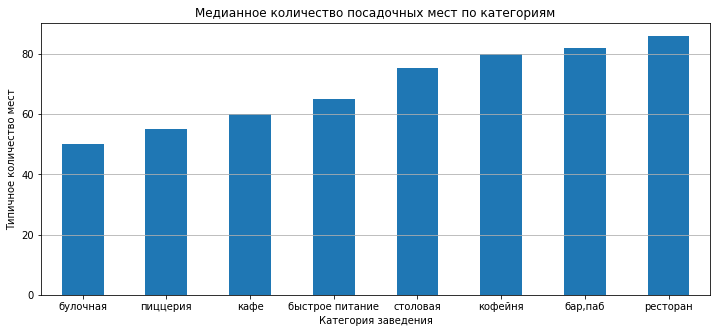

In [54]:
# Построим столбчатую диаграмму для наглядности
cat_by_seats.plot(
kind='bar',
figsize=(12, 5),
title='Медианное количество посадочных мест по категориям',
xlabel='Категория заведения',
ylabel='Типичное количество мест',
rot=0)

plt.grid(axis='y')

Для разных категорий заведений типичное количество посадочных мест отличается, но в целом остаётся относительно небольшим. Минимальная медианная вместимость у булочных (около 50 мест), пиццерий (55) и кафе (60) — это компактные форматы. Быстрое питание и столовые немного крупнее (примерно 65–76 мест). Наибольшее медианное количество посадочных мест у кофеен, баров/пабов и ресторанов. Выбросы (крупные заведения с 300+ мест) оставлены в данных, но для оценки «типичного» количества мест использовалась медиана, которая мало чувствительна к таким значениям.

---

### Задача 5



In [55]:
# Средний рейтинг по категориям
rating_by_cat = df.groupby('category')['rating'].mean().sort_values()
rating_by_cat

category
быстрое питание    4.050249
кафе               4.124285
столовая           4.211429
булочная           4.268359
кофейня            4.277282
ресторан           4.290402
пиццерия           4.301264
бар,паб            4.387696
Name: rating, dtype: float64

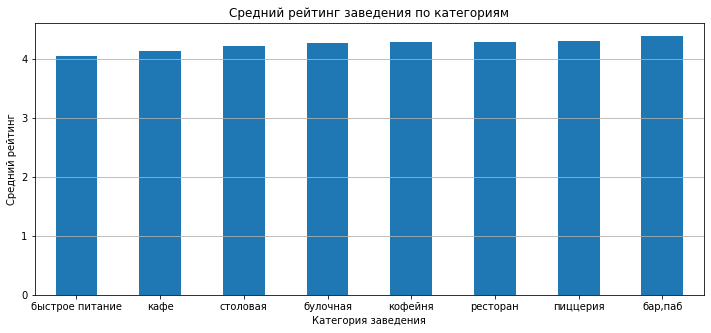

In [56]:
# Построим столбчатую диаграмму для наглядности
rating_by_cat.plot(
              kind='bar',
              figsize=(12,5),
              rot=0)

plt.title('Средний рейтинг заведения по категориям')
plt.ylabel('Средний рейтинг')
plt.xlabel('Категория заведения')
plt.grid(axis='y')



Средние рейтинги во всех категориях лежат в узком диапазоне от 4.05 до 4.39 балла, то есть посетители в целом оценивают заведения достаточно высоко и существенных различий нет. Немного ниже среднего выглядят точки быстрого питания (около 4.05), а самые высокие оценки получают бары/пабы (приблизительно 4.39), пиццерии и рестораны.

---

### Задача 6



In [57]:
cols = ['rating',
      'category',
      'district',
      'chain',
      'seats',
      'price',
      'is_24_7']

df_phik = df[cols] 

# Вычисляем корреляционную матрицу
correlation_matrix = df_phik.phik_matrix(interval_cols = ['rating', 'chain', 'seats'])
correlation_matrix

,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.189716,0.200761,0.107833,0.000000,0.220295,0.144951
category,0.189716,1.000000,0.174584,0.266000,0.048923,0.566933,0.230250
district,0.200761,0.174584,1.000000,0.064473,0.352440,0.202787,0.065881
chain,0.107833,0.266000,0.064473,1.000000,0.056523,0.218211,0.050736
seats,0.000000,0.048923,0.352440,0.056523,1.000000,0.065308,0.038072
price,0.220295,0.566933,0.202787,0.218211,0.065308,1.000000,0.066287
is_24_7,0.144951,0.230250,0.065881,0.050736,0.038072,0.066287,1.000000


In [58]:
# Корреляция только с рейтингом
corr_with_rating = correlation_matrix['rating'].sort_values(ascending=False)
corr_with_rating

rating      1.000000
price       0.220295
district    0.200761
category    0.189716
is_24_7     0.144951
chain       0.107833
seats       0.000000
Name: rating, dtype: float64

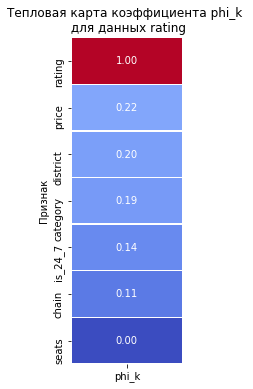

In [59]:
# Построим тепловую карту
plt.figure(figsize=(2, 6))

sns.heatmap(
    corr_with_rating.to_frame(name='phi_k'),  # превратим в DataFrame
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=False)

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.ylabel('Признак')

plt.show()
          

Наибольшие значения phi_k у price (0.22), district (0.20) и category (0.19), то есть тип заведения, район и ценовая категория немного влияют на рейтинг, но не сильно. Круглосуточность - is_24_7 (0.14) и принадлежность к сети - chain (0.11) слабо влияют на рейтинг. Количество посадочных мест - seats (0.00) никак не влияют на рейтинг заведения.

---

### Задача 7



In [60]:
# Считаем сколько заведений у каждой сети
chains_stats = df_chain.groupby('name').agg(n_places=('id', 'nunique'),
                                            mean_rating=('rating', 'mean')).sort_values('n_places', ascending=False)
chains_stats

,n_places,mean_rating
name,,
Шоколадница,120,4.177500
Домино'с Пицца,76,4.169737
Додо Пицца,74,4.286486
One Price Coffee,71,4.064789
Яндекс Лавка,69,3.872464
...,...,...
Радуга,1,4.800000
Чай,1,3.700000
Чабан Чуду,1,4.400000


In [61]:
# Выводим топ
top_15 = chains_stats.head(15).reset_index()
top_15

,name,n_places,mean_rating
0,Шоколадница,120,4.177500
1,Домино'с Пицца,76,4.169737
2,Додо Пицца,74,4.286486
3,One Price Coffee,71,4.064789
4,Яндекс Лавка,69,3.872464
5,Cofix,65,4.075385
6,Prime,50,4.116000
7,Хинкальная,44,4.322727
8,КОФЕПОРТ,42,4.147619
9,Кулинарная лавка братьев Караваевых,39,4.394872


In [62]:
# Для каждой сети берём одну категорию (первую по встречаемости)
cats = df_chain.groupby('name', as_index=False).agg(category=('category', 'first'))

top_15_final = top_15.merge(cats, on='name', how='left')
top_15_final

,name,n_places,mean_rating,category
0,Шоколадница,120,4.177500,кофейня
1,Домино'с Пицца,76,4.169737,пиццерия
2,Додо Пицца,74,4.286486,пиццерия
3,One Price Coffee,71,4.064789,кофейня
4,Яндекс Лавка,69,3.872464,ресторан
5,Cofix,65,4.075385,кофейня
6,Prime,50,4.116000,ресторан
7,Хинкальная,44,4.322727,быстрое питание
8,КОФЕПОРТ,42,4.147619,кофейня
9,Кулинарная лавка братьев Караваевых,39,4.394872,кафе


<div class="alert alert-info">
<b> Вывод</b> 
</div>

В топ‑15 сетей по количеству заведений входят в основном кофейни, пиццерии, кафе и рестораны. Лидером по числу точек является «Шоколадница» (кофейня), далее идут «Домино’с Пицца» и «Додо Пицца» (пиццерии), One Price Coffee и Cofix (кофейни), а также крупные сети ресторанного формата («Яндекс Лавка», Prime, «Теремок»). Средние рейтинги у всех сетей из топ‑15 находятся примерно в диапазоне от 3.9 до 4.4 балла, при этом относительно более высокие оценки у «Буханки» (булочная) и «Кулинарной лавки братьев Караваевых» (кафе). Это говорит о том, что самые масштабные сети в основном работают в популярных форматах кофеен, пиццерий и кафе, ресторанов и при этом удерживают стабильно высокий средний рейтинг

---

### Задача 8




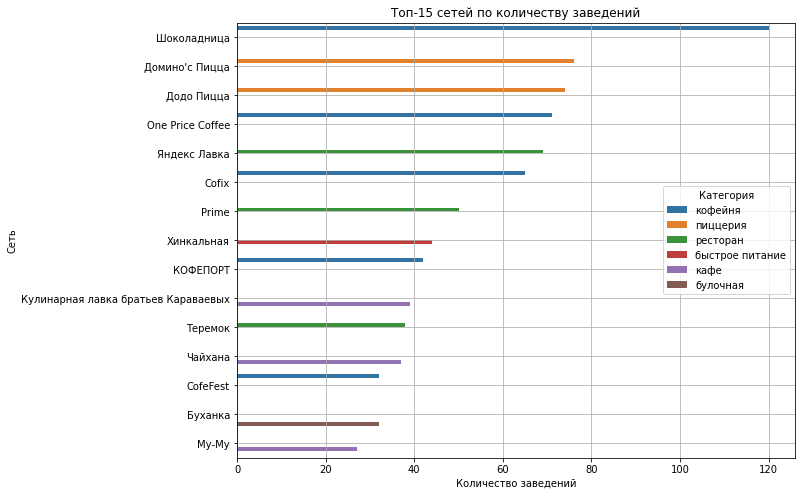

In [63]:
# Построим линейчатую диграмму
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_15_final,
    x='n_places',
    y='name',
    hue='category'
)

plt.xlabel('Количество заведений')
plt.ylabel('Сеть')
plt.title('Топ-15 сетей по количеству заведений')
plt.legend(title='Категория')
plt.grid()



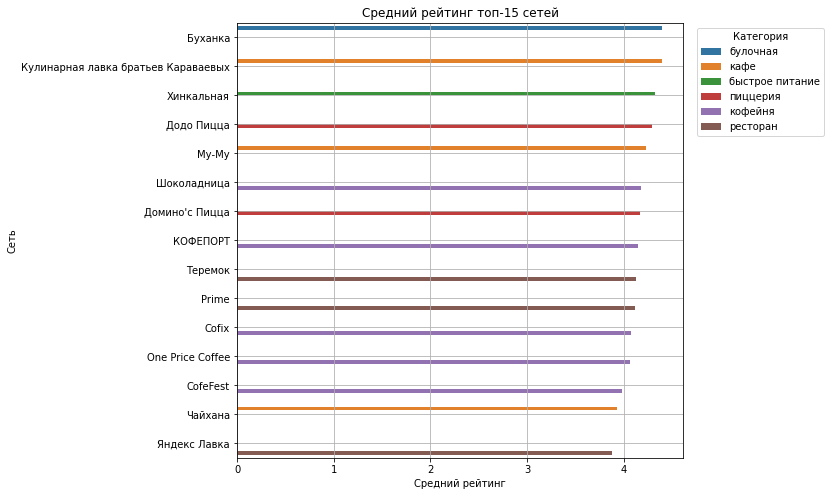

In [64]:
plt.figure(figsize=(8, 8))


sns.barplot(
    data=top_15_final.sort_values('mean_rating', ascending=False),
    x='mean_rating',
    y='name',
    hue='category'
)

plt.xlabel('Средний рейтинг')
plt.ylabel('Сеть')
plt.title('Средний рейтинг топ-15 сетей')
plt.legend(title='Категория', bbox_to_anchor=(1.02, 1), loc='upper left')


plt.grid()


По количеству точек лидируют «Шоколадница», «Домино’с Пицца», «Додо Пицца», One Price Coffee, «Яндекс Лавка», Cofix — это в основном кофейни, пиццерии и рестораны. По среднему рейтингу среди топ‑15 чуть выделяется «Буханка» и «Кулинарная лавка братьев Караваевых», при этом крупные сети типа «Шоколадницы», «Додо Пиццы» и «Му‑Му» удерживают рейтинг около 4.1–4.3 балла.

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

Коэффициенты phi_k для всех признаков невысокие (до 0.22), значит, рейтинг слабо зависит от изученных факторов. Чуть сильнее всего рейтинг связан с ценовой категорией, округом и типом заведения: более дорогие заведения и некоторые категории (например, рестораны) имеют немного более высокий средний рейтинг, но без резких различий. Круглосуточный режим работы, принадлежность к сети и количество посадочных мест практически не влияют на рейтинг: различия в оценках между такими группами минимальны.

Топ‑15 по количеству точек составляют в основном кофейни, пиццерии, кафе и рестораны: «Шоколадница», «Домино’с Пицца», «Додо Пицца», One Price Coffee, «Яндекс Лавка», Cofix, «Теремок», «Кулинарная лавка братьев Караваевых», «Буханка» и др. Лидером по числу заведений является «Шоколадница», далее идут крупные пиццерии и кофейные сети. Средний рейтинг у сетей из топ‑15 держится примерно в диапазоне 3.9–4.4. Относительно более высокие средние оценки у «Буханки» и «Кулинарной лавки братьев Караваевых», при этом крупные сети вроде «Додо Пиццы», «Домино’с Пицца», «Шоколадницы» и «Му‑Му» также показывают стабильные рейтинги выше 4 баллов. Основные различия в рейтинге задаются не столько формальными характеристиками (категория, район, принадлежность к сети, круглосуточность, размер зала), сколько другими факторами, не представленными в датасете (например, качество кухни, сервис, атмосфера и т.п.)

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

1. Общий обзор проделанной работы.

В рамках проекта были загружены и объединены данные о заведениях общественного питания Москвы: их тип, рейтинг, принадлежность к сети, количество посадочных мест, ценовая категория, режим работы и расположение по административным округам. Проведена очистка и предобработка данных, изучены распределения ключевых признаков и выявлены пропуски и аномалии. Далее выполнен исследовательский анализ: сравнение типов заведений, сетевых и несетевых объектов, анализ популярных форматов и сетей, а также оценка зависимости рейтинга от различных характеристик.

2. Ответы на исследовательские вопросы, или главные выводы.

Наиболее массовый формат — кафе и рестораны, затем кофейни. Именно эти типы дают основную долю рынка по количеству точек.

 Одиночные заведения заметно преобладают над сетями в выборке. многие крупные сети (Шоколадница, Додо Пицца, Домино’с, One Price Coffee и др.) представлены десятками точек и имеют высокие средние рейтинги (около 4 баллов).

Административные округа различаются по числу заведений: больше всего заведений сосредоточено в Центральном округе, заметно отстают Северный, Южный, Северо-Восточный и остальные округа. Меньше всего заведений в Северо-Западном округе. Такое распределение логично отражает концентрацию бизнеса и туристической активности в центре города.

Корреляционный анализ показал, что связь рейтинга с ценовой категорией, с числом посадочных мест, форматом заведения и другими признаками есть, но она не слишком сильная. На оценку гостей влияет множество других факторов.

3. Рекомендации на основе анализа данных.

Ориентироваться на наиболее популярные форматы (кафе, кофейня, ресторан или пиццерия), так как они демонстрируют устойчивый спрос и высокие средние рейтинги.

Раз рейтинг слабо зависит от формальных признаков, конкурировать придётся за счёт качества кухни, сервиса и атмосферы.

При выборе локации важно учитывать насыщенность района заведениями. В центральных и популярных округах высокая конкуренция, но и больший поток гостей. В спальных районах можно занять свободную нишу с меньшей конкуренцией, особенно в формате кафе/кофейни.

В долгосрочной перспективе стоит закладывать возможность масштабирования до сети. Крупнейшие сети присутствуют в десятках локаций и при этом сохраняют средний рейтинг не ниже 4, что говорит о преимуществах стандартизации процессов.

Поскольку рейтинг слабо объясняется текущими признаками, заказчику имеет смысл дополнительно собирать данные о качестве кухни, скорости обслуживания, чистоте, отзывах гостей и т.п.